 Titanic Dataset - Mini EDA

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 Load Dataset

In [48]:
df = pd.read_csv('/content/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset Information

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [50]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [51]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Data Cleaning

In [52]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [53]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [54]:
df.drop(columns=['Cabin'], inplace=True)

In [55]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Create Age Groups

In [56]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,30,50,80],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)

df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


Insight

Passengers were divided into age categories to better analyze survival patterns across different age groups.

 Survival Rate by Age Group

In [57]:
df.groupby('AgeGroup', observed=False)['Survived'].mean()

,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Young Adult,0.331096
Adult,0.423237
Senior,0.343750


Visualization

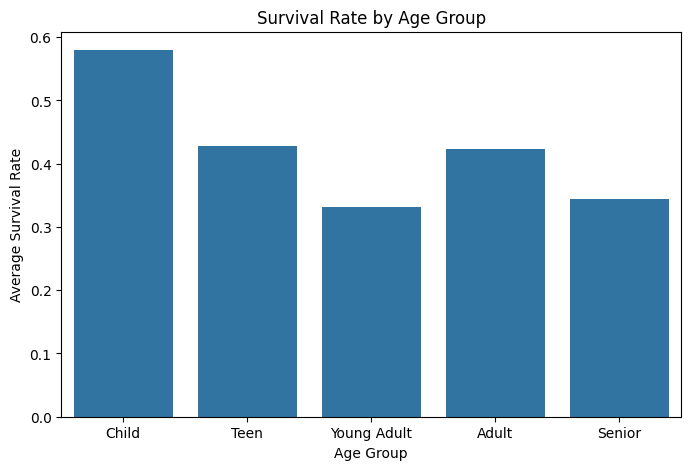

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Survived',
    errorbar=None
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Survival Rate")

plt.show()

Insight

The bar chart shows that children had the highest survival rate (approximately 58%), indicating they were more likely to survive the Titanic disaster. Young adults had the lowest survival rate (around 33%), while teenagers, adults, and seniors had moderate survival rates between 34% and 43%. This suggests that age influenced survival, with children receiving a higher chance of rescue.


 Survival Rate by Embarkation Port

In [59]:
df.groupby('Embarked')['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


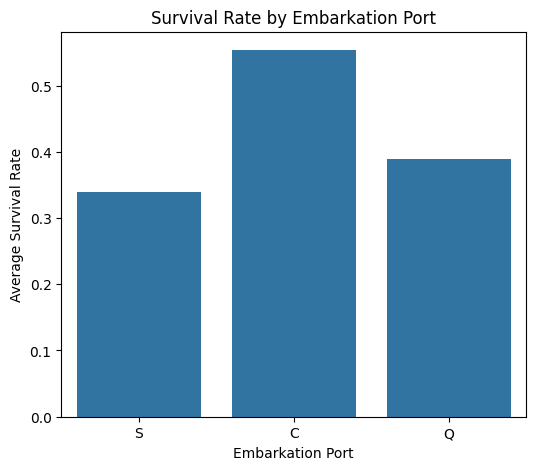

In [60]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x='Embarked',
    y='Survived',
    errorbar=None
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Average Survival Rate")

plt.show()

Insight

The analysis shows that passengers who embarked from Cherbourg (Port C) had the highest survival rate (approximately 55%), while passengers from Southampton (Port S) had the lowest survival rate (around 34%). This indicates that the embarkation port may have influenced survival, possibly due to differences in passenger class distribution and cabin locations.

Family Size Feature

In [61]:
df['FamilySize'] = df['SibSp'] + df['Parch']

df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


Survival Rate by Family Size

In [62]:
df.groupby('FamilySize')['Survived'].mean()

,Survived
FamilySize,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


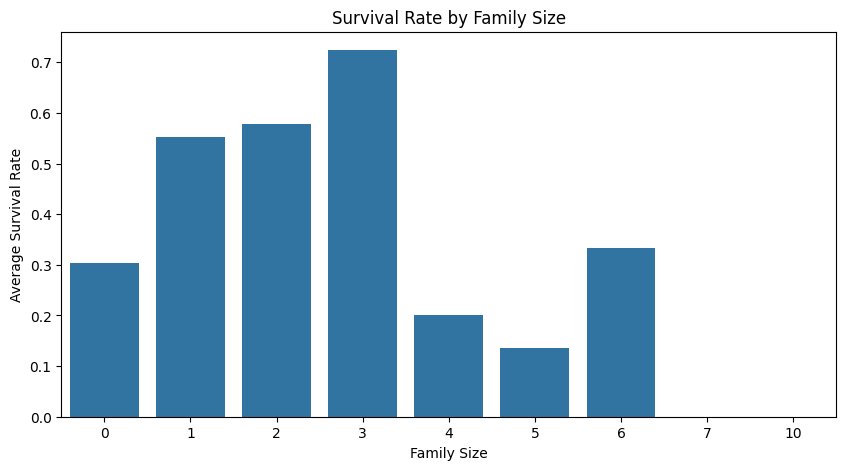

In [63]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='FamilySize',
    y='Survived',
    errorbar=None
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")

plt.show()

 Insight

The analysis shows that passengers traveling with small families (1–3 members) had higher survival rates than those traveling alone or in very large families. The highest survival rate was observed for passengers with a family size of 3, while larger family sizes (4 and above) generally had lower survival rates. This suggests that moderate family sizes may have provided a better chance of survival during the disaster.

Age Distribution (Histogram)

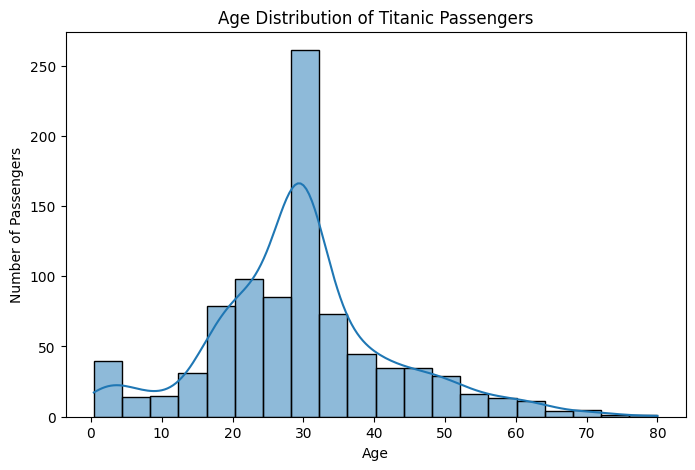

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True
)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Insight

The histogram shows that most passengers were between 20 and 40 years of age, indicating that young adults formed the largest group on the Titanic. Very few passengers were above 60 years of age.

Correlation Heatmap

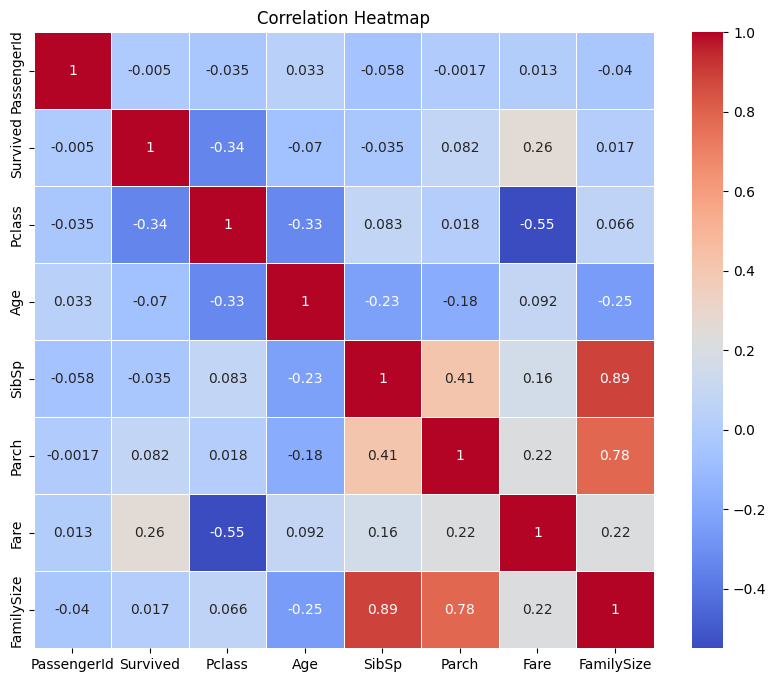

In [65]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

 Insight

The heatmap indicates that passenger class (Pclass) has a negative correlation with survival, meaning passengers in higher classes had better chances of survival. Fare shows a positive correlation with survival, while Age has only a weak relationship with survival.



  Conclusion

- Successfully performed Exploratory Data Analysis (EDA) on the Titanic dataset to understand factors affecting passenger survival.
- Cleaned the dataset by handling missing values through imputation and removing the irrelevant Cabin column.
- Created new features such as **AgeGroup** and **FamilySize** to gain deeper insights into survival patterns.
- Analyzed survival rates based on age group, embarkation port, and family size using GroupBy operations.
- Developed meaningful visualizations, including bar plots, a histogram, and a correlation heatmap, to effectively present the findings.
- Observed that children had the highest survival rate, passengers embarking from Cherbourg (Port C) were more likely to survive, and travelers with small families generally had better survival chances.
- Identified relationships between numerical features using a correlation heatmap, enhancing the understanding of the dataset.
- Strengthened practical skills in data cleaning, feature engineering, exploratory data analysis, data visualization, and data storytelling using Python libraries such as Pandas, Matplotlib, and Seaborn.